# PCA for Parsimony — Fewer Inputs, Same Information

The previous notebook reduced the feature count by *choosing* a subset. PCA does something
different: it keeps information from **all** the features but repackages it into fewer columns, by
rotating onto the directions of greatest variance and keeping only the leading ones.

We sweep the number of components from 1 to 50 and watch two very different models respond, which
exposes what PCA does and does not guarantee.

## Learning objectives

- Transform features into principal components and retain the leading $k$
- Fit PCA on the training split only, and explain why transforming before splitting leaks
- Read a score-vs-components curve to choose $k$
- Explain why PCA, being unsupervised, does not order components by usefulness for the target

## Background

This notebook assumes $R^2$, the train/test split, and PCA's mechanics from `U1-2_Preprocess`
section 1.4 — the eigendecomposition of the covariance matrix and the resulting uncorrelated
components. Here that transform is used for *dimensionality reduction* rather than decorrelation.

**Prerequisites:** `U1-2_Preprocess` (PCA mechanics), `U1-3_Regression-1_ModelCompare` ($R^2$)

**Dataset:** none — 1,000 samples with 50 features from `sklearn.datasets.make_regression`.

**References:** https://scikit-learn.org/stable/modules/decomposition.html#pca

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)
pd.set_option("display.precision", 4)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Create the data

Fifty features, a linear target, and light noise. `make_regression` uses only a subset of the
features to build $y$, so there is genuine redundancy for PCA to compress.

In [2]:
from sklearn import datasets
from sklearn.metrics import r2_score

n_feat = 50

X, y = datasets.make_regression(
    n_samples=1000,
    n_features=n_feat,
    noise=1,
    random_state=42
)

## 2. Train/test split

In [3]:
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

## 3. PCA

PCA finds the eigenvectors of the covariance matrix and projects onto them, ordered so the first
component captures the most variance, the second the most of what remains, and so on. Keeping the
leading $k$ gives the best $k$-dimensional linear summary of the data in a squared-error sense.

Watch the two lines carefully:

```python
X_train_pca = pca.fit_transform(X_train)   # fit AND transform
X_test_pca  = pca.transform(X_test)        # transform only
```

The rotation is learned from the **training data alone** and then applied to the test data. Calling
`fit_transform` on the full array before splitting would let the test set influence the axes, which
is leakage — the same rule as scalers in `U1-2_Preprocess`, and easy to get wrong because PCA never
looks at $y$ and so feels harmless.

All 50 components are computed here; the sweep below chooses how many to *use*.

In [4]:
from sklearn.decomposition import PCA

# Apply PCA on training data
pca = PCA(n_components=n_feat)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

## 4. Modeling — score vs. number of components

Fit two very different models on the first $k$ components, for every $k$ from 1 to 50.

Because the components are ordered by variance, taking the first $k$ columns is exactly "keep the
$k$ most-variance-carrying directions." The two models are chosen to disagree: `LinearRegression`
can use every component it is given, while a depth-limited `RandomForestRegressor` has finite
capacity and must spend it.

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from tqdm import tqdm

# Initialize models
rf = RandomForestRegressor(n_estimators=100, max_depth=5)
lr = LinearRegression()

# Store R² scores
rf_train_r2, rf_test_r2 = [], []
lr_train_r2, lr_test_r2 = [], []

# Loop over number of PCA components
for k in tqdm(range(1, n_feat + 1), ncols=50):
    X_train_k = X_train_pca[:, :k]
    X_test_k = X_test_pca[:, :k]

    # Random Forest
    rf.fit(X_train_k, y_train)
    rf_train_r2.append(r2_score(y_train, rf.predict(X_train_k)))
    rf_test_r2.append(r2_score(y_test, rf.predict(X_test_k)))

    # Linear Regression
    lr.fit(X_train_k, y_train)
    lr_train_r2.append(r2_score(y_train, lr.predict(X_train_k)))
    lr_test_r2.append(r2_score(y_test, lr.predict(X_test_k)))

  0%|                      | 0/50 [00:00<?, ?it/s]

  2%|▎             | 1/50 [00:00<00:05,  8.43it/s]

  4%|▌             | 2/50 [00:00<00:06,  7.84it/s]

  6%|▊             | 3/50 [00:00<00:06,  7.17it/s]

  8%|█             | 4/50 [00:00<00:07,  6.52it/s]

...

 94%|████████████▏| 47/50 [00:29<00:03,  1.08s/it]

 96%|████████████▍| 48/50 [00:30<00:02,  1.11s/it]

 98%|████████████▋| 49/50 [00:31<00:01,  1.12s/it]

100%|█████████████| 50/50 [00:32<00:00,  1.14s/it]

100%|█████████████| 50/50 [00:32<00:00,  1.52it/s]

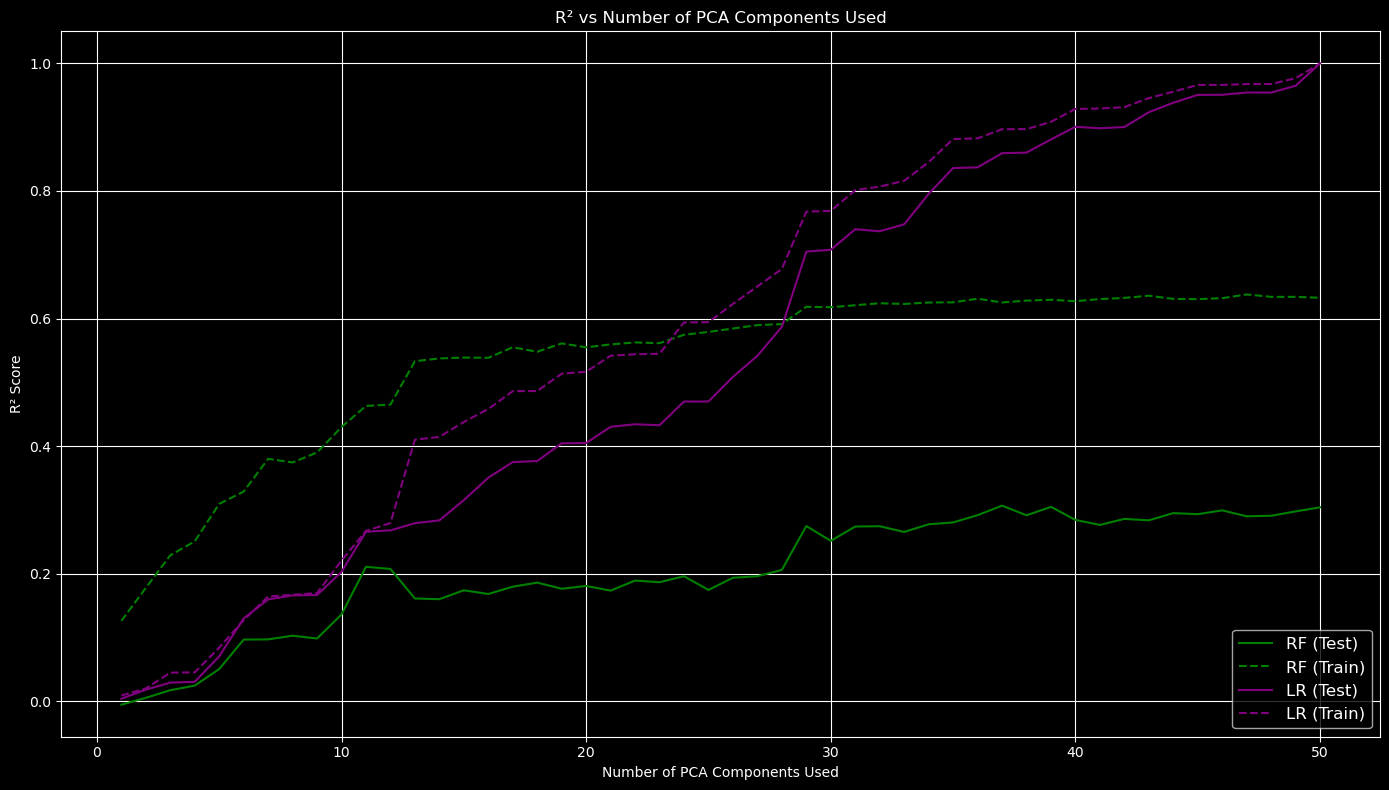

In [6]:
# Plotting
x = np.arange(1, n_feat + 1)
plt.figure(figsize=(14, 8))

# Random Forest (green)
plt.plot(x, rf_test_r2, color='green', label='RF (Test)')
plt.plot(x, rf_train_r2, '--', color='green', label='RF (Train)')

# Linear Regression (purple)
plt.plot(x, lr_test_r2, color='purple', label='LR (Test)')
plt.plot(x, lr_train_r2, '--', color='purple', label='LR (Train)')

plt.xlabel("Number of PCA Components Used")
plt.ylabel("R² Score")
plt.title("R² vs Number of PCA Components Used")
plt.legend(loc='lower right', fontsize='large')
plt.grid(True)
plt.tight_layout()
plt.show()

Read the two pairs of curves separately.

**Linear regression** should climb quickly and then flatten. Since the target is a linear function
of the original features and PCA is a linear rotation, once enough components are retained to span
the directions the target depends on, nothing further is gained — and nothing is lost either.

**Random forest** behaves differently, and this is the interesting part. Its test curve can *peak
and decline*, because extra components dilute the useful signal across more candidate split
variables while adding no information the model can use.

The deeper point is that **PCA is unsupervised**. It orders components by variance in $X$, and never
looks at $y$. A direction of large variance is not necessarily a direction that predicts the target
— it is entirely possible for the signal to live in a low-variance component that PCA ranks last.
That is the standing risk of PCA as a feature-reduction step, and the reason to check a curve like
this rather than defaulting to "keep 95% of the variance."

## 5. Review

- **PCA compresses rather than selects.** Every original feature contributes to every component,
  unlike the subset selection of `U1-4_FeatSelect-2_FeatureImportance`.
- **Components are ordered by variance explained**, so keeping the first $k$ is the best linear
  $k$-dimensional summary of $X$ in a squared-error sense.
- **Fit on train, transform test.** PCA never sees $y$, which makes the leakage easy to overlook —
  it is leakage all the same.
- **Linear regression saturates; the forest can peak and decline.** More components are not free
  for a model with limited capacity.
- **PCA is unsupervised and can rank the useful direction last.** High variance in $X$ does not
  mean high relevance to $y$, so validate $k$ with a curve rather than a variance threshold.